In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")

pd.set_option("display.max_colwidth", 300)


In [6]:
DATA_PATH = "../../data/raw/"

hotel1 = pd.read_csv(DATA_PATH + "hotel_reviews_andrewmvd.csv", encoding="latin1")
hotel2 = pd.read_csv(DATA_PATH + "hotel_reviews_devastator.csv", encoding="latin1")
restaurant = pd.read_csv(DATA_PATH + "restaurant_reviews_tripadvisor.csv", encoding="latin1")

print("Hotel1:", hotel1.shape)
print("Hotel2:", hotel2.shape)
print("Restaurant:", restaurant.shape)


Hotel1: (20491, 2)
Hotel2: (20491, 3)
Restaurant: (1216, 3)


In [7]:
hotel1.head()


,Review,Rating
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music...",4
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like tv couch ect desk clerk told oh mixed suites descr...",2
2,"nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized, missed 3 separate wakeup calls, concierge busy hard touch, did n't pro...",3
3,"unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed no signs animal hair smells, monaco suite sleeping area big striped curtains pulled closed nice touch felt cosy, goldfish named brandi enjoyed, did n't partake f...",5
4,"great stay great stay, went seahawk game awesome, downfall view building did n't complain, room huge staff helpful, booked hotels website seahawk package, no charge parking got voucher taxi, problem taxi driver did n't want accept voucher barely spoke english, funny thing speak arabic called sta...",5


In [8]:
hotel2.head()


,S.No.,Review,Rating
0,1,nice hotel expensive parking got good deal stay hotel anniversary \tarrived late evening took advice previous reviews did valet parking \tcheck quick easy \tlittle disappointed non-existent view room room clean nice size \tbed comfortable woke stiff neck high pillows \tnot soundproof like heard ...,4
1,2,ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle \tstart booked suite paid extra website description not \tsuite bedroom bathroom standard hotel room \ttook printed reservation desk showed said things like tv couch ect desk clerk told oh mixed suites de...,2
2,3,nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized \tmissed 3 separate wakeup calls \tconcierge busy hard touch \tdid n't ...,3
3,4,unique \tgreat stay \twonderful time hotel monaco \tlocation excellent short stroll main downtown shopping area \tpet friendly room showed no signs animal hair smells \tmonaco suite sleeping area big striped curtains pulled closed nice touch felt cosy \tgoldfish named brandi enjoyed \tdid n't pa...,5
4,5,great stay great stay \twent seahawk game awesome \tdownfall view building did n't complain \troom huge staff helpful \tbooked hotels website seahawk package \tno charge parking got voucher taxi \tproblem taxi driver did n't want accept voucher barely spoke english \tfunny thing speak arabic cal...,5


In [9]:
restaurant.head()


,Review Date,Review Text,Rating
0,"March 4, 2024",Had an amazing dinner with family. Today our special day . It was great dayThe staff were amazingly friendly. Made our special night very special. Thank you.,5.0
1,"March 4, 2024",Tonight dinner was wonderful dinner. I went my full family to enjoy our dinner. Food taste ð¯/ ð¯. All over excellent. Service was very good.,5.0
2,"March 4, 2024",Wide spread of buffet dinner. Really enjoyed it with our whole family. Delicious. My favourite place in Dhaka city. Thanks to all of you.,5.0
3,"February 27, 2024",Food at Seasonal taste was really delicious. Particularly the dessert section. Really enjoyed it. Service was excillent,5.0
4,"February 26, 2024",It was a great experience considering both the food and ambience. Top notch service. Hope to come again... Thank you ððð,5.0


In [10]:
for name, df in {
    "hotel1": hotel1,
    "hotel2": hotel2,
    "restaurant": restaurant
}.items():
    print("\n", "="*40)
    print(name.upper())
    print(df.info())



HOTEL1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None

HOTEL2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   S.No.   20491 non-null  int64 
 1   Review  20491 non-null  object
 2   Rating  20491 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 480.4+ KB
None

RESTAURANT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1216 entries, 0 to 1215
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Review Date  1216 non-null   object 
 1   Review Text  1216 non-null   object 
 2   Rating       1216 non-null   float64
dt

In [16]:
hotel1 = hotel1.rename(columns={
    "Review": "review_text",
    "Rating": "rating"
})

hotel2 = hotel2.rename(columns={
    "Review": "review_text",
    "Rating": "rating"
})

restaurant = restaurant.rename(columns={
    "Review Text": "review_text",
    "rating": "rating"   # already lowercase but keeping consistent
})

In [18]:
hotel1 = hotel1[["review_text", "rating"]]
hotel2 = hotel2[["review_text", "rating"]]
restaurant = restaurant[["review_text", "rating"]]


In [19]:
hotel1["category"] = "hotel"
hotel2["category"] = "hotel"
restaurant["category"] = "restaurant"


In [20]:
df = pd.concat([hotel1, hotel2, restaurant], ignore_index=True)

df.shape


(42198, 3)

In [21]:
df.isnull().sum()


review_text    0
rating         0
category       0
dtype: int64

In [22]:
df.duplicated().sum()


np.int64(2)

In [23]:
df = df.dropna(subset=["review_text", "rating"])
df = df.drop_duplicates()

df.shape


(42196, 3)

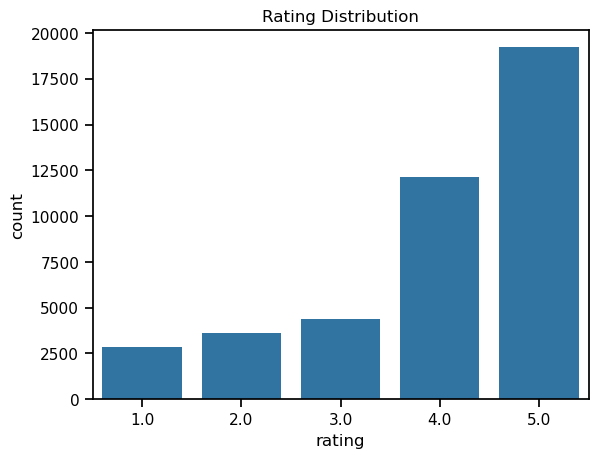

In [24]:
plt.figure()
sns.countplot(x="rating", data=df)
plt.title("Rating Distribution")
plt.show()


In [25]:
def rating_to_sentiment(r):
    if r >= 4:
        return "positive"
    elif r <= 2:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)
df["sentiment"].value_counts()


sentiment
positive    31376
negative     6440
neutral      4380
Name: count, dtype: int64

In [26]:
df = df[df["sentiment"] != "neutral"]
df["sentiment"].value_counts()


sentiment
positive    31376
negative     6440
Name: count, dtype: int64

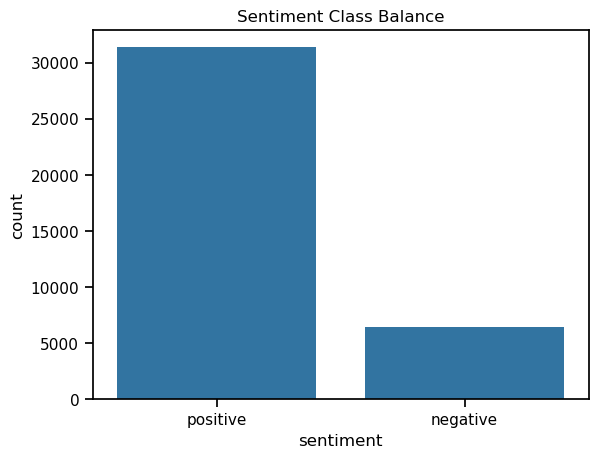

In [27]:
plt.figure()
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Class Balance")
plt.show()


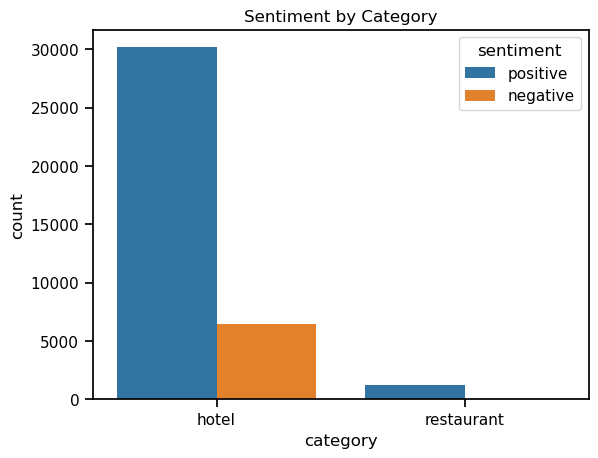

In [28]:
plt.figure()
sns.countplot(x="category", hue="sentiment", data=df)
plt.title("Sentiment by Category")
plt.show()


In [29]:
df["char_count"] = df["review_text"].astype(str).apply(len)
df["word_count"] = df["review_text"].astype(str).apply(lambda x: len(x.split()))


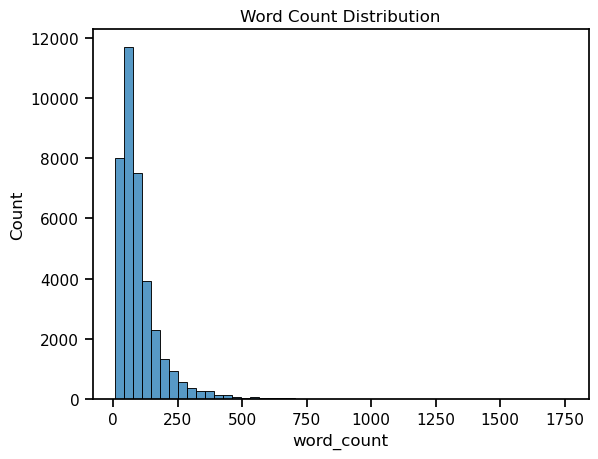

In [30]:
plt.figure()
sns.histplot(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()


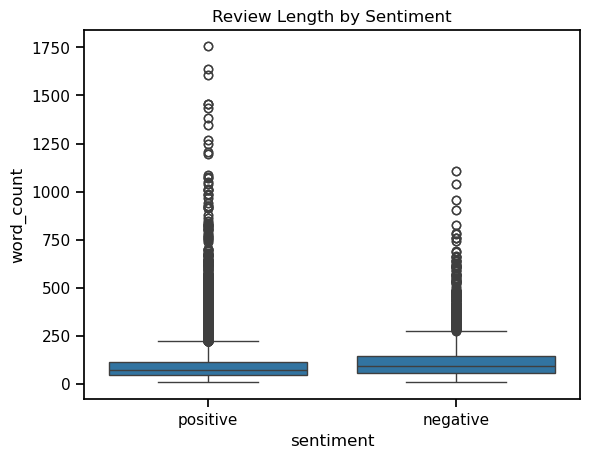

In [31]:
plt.figure()
sns.boxplot(x="sentiment", y="word_count", data=df)
plt.title("Review Length by Sentiment")
plt.show()


In [32]:
df.sort_values("word_count", ascending=False).head(5)[["review_text", "word_count"]]


,review_text,word_count
7049,"false start good vacation secrets__Ã, false start good dominican vacationsunday 12/4/05 snow falling, it__Ã_Ã©_ 0-dark-thirty newton ma airport shuttle cruises mass turnpike inbound boston__Ã_Ã©_ logan airport, snow halos pike__Ã_Ã©_ flood lamps swirls eddies vehicles road morning, we__Ã_Ã©...",1755
27540,false start good vacation secrets__Ç \tfalse start good dominican vacationsunday 12/4/05 snow falling \tit__Ç_é_ 0-dark-thirty newton ma airport shuttle cruises mass turnpike inbound boston__Ç_é_ logan airport \tsnow halos pike__Ç_é_ flood lamps swirls eddies vehicles road morning \twe__Ç_ée in...,1755
13003,"awesome vacation sirenis punta cana arrival flight long detailed review, arrived sunday august 3rd stayed sunday august 10th 2008. booked apple vacations able great deal 8 day/7 night stay detroit, deal worth 3.5 hour drive detroit, flew usa3000 charter airlines, left time maybe arrived early, v...",1639
33494,awesome vacation sirenis punta cana arrival flight long detailed review \tarrived sunday august 3rd stayed sunday august 10th 2008. booked apple vacations able great deal 8 day/7 night stay detroit \tdeal worth 3.5 hour drive detroit \tflew usa3000 charter airlines \tleft time maybe arrived earl...,1639
17777,"fantastic return trip, firstly apology length review, knew long share know love reading reviews hope pleasure, 25th 8th june, 2nd trip resort year honeymoon june 2007 sunscape beach.i tried break categories easier read.airport flight4 flew newcastle thomson, prebooked paid airport lounge 6.30am ...",1608


In [33]:
OUTPUT_PATH = "../../data/processed/"

df.to_csv(OUTPUT_PATH + "combined_reviews_base.csv", index=False)


<Axes: >

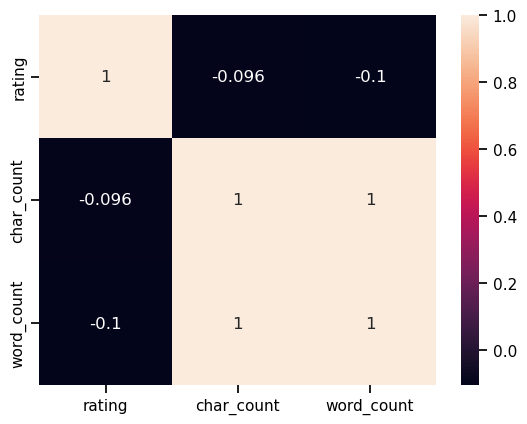

In [34]:
sns.heatmap(df[["rating","char_count","word_count"]].corr(), annot=True)


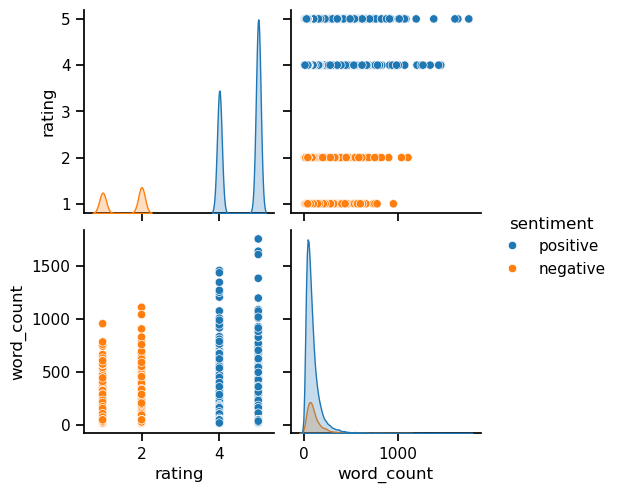

In [35]:
sns.pairplot(df, vars=["rating","word_count"], hue="sentiment")


In [36]:
df.groupby(["category","sentiment"])["word_count"].mean()


category    sentiment
hotel       negative     120.308494
            positive      99.488703
restaurant  negative      39.916667
            positive      26.612605
Name: word_count, dtype: float64

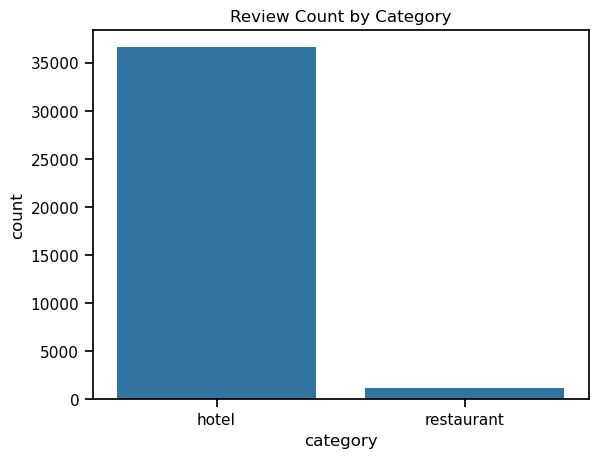

In [37]:
plt.figure()
sns.countplot(x="category", data=df)
plt.title("Review Count by Category")
plt.show()


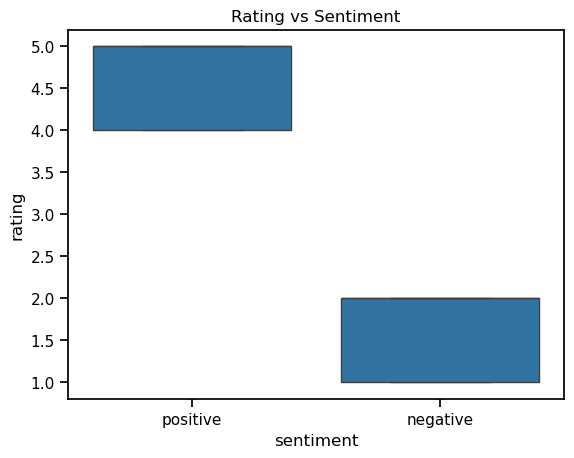

In [38]:
plt.figure()
sns.boxplot(x="sentiment", y="rating", data=df)
plt.title("Rating vs Sentiment")
plt.show()


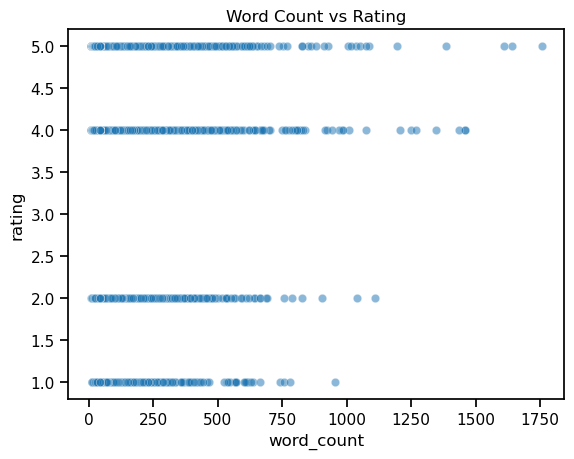

In [39]:
plt.figure()
sns.scatterplot(x="word_count", y="rating", data=df, alpha=0.3)
plt.title("Word Count vs Rating")
plt.show()


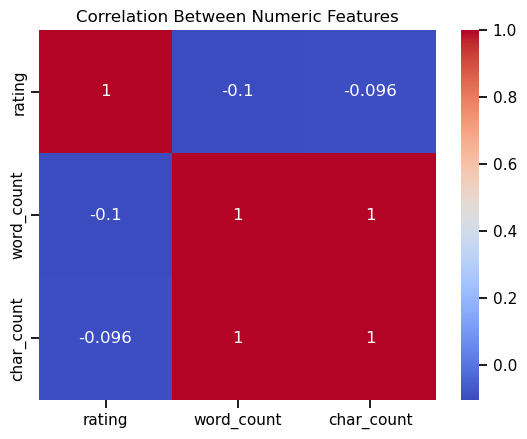

In [40]:
num_cols = ["rating", "word_count", "char_count"]

plt.figure()
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()


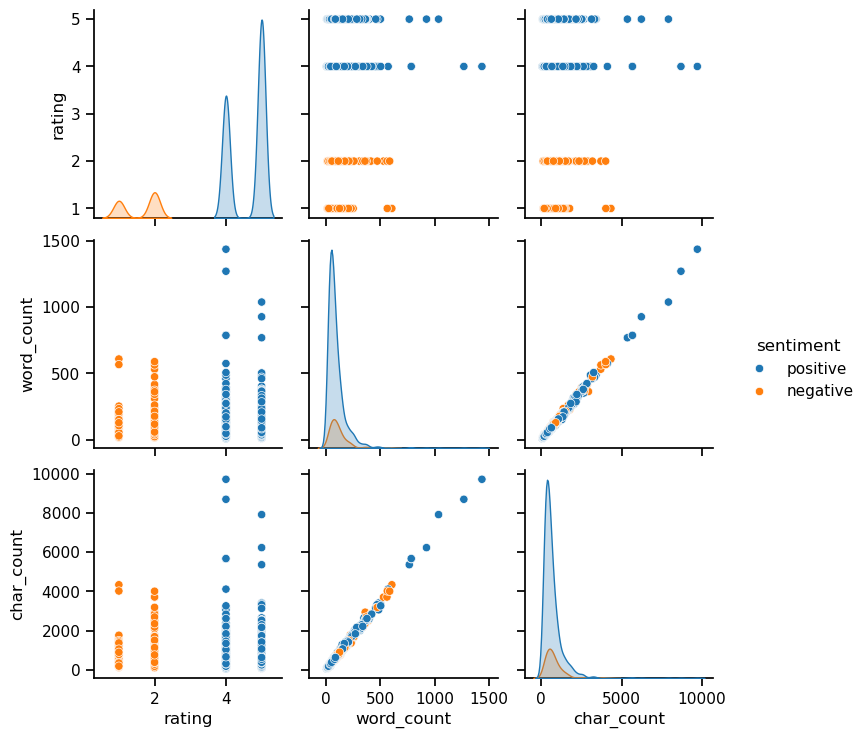

In [41]:
sns.pairplot(df.sample(2000), vars=num_cols, hue="sentiment")
